# 📊 Netflix Data Analysis

### Objective
The goal of this project is to analyze Netflix content and uncover trends in movies and TV shows.

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [82]:
df=pd.read_csv('https://drive.google.com/uc?export=download&id=1r6DwJyOJxr6VKcdPXfwY4Ded8_jdnw8P')

## Dataset Overview
The dataset contains information about Netflix movies and TV shows including type, country, genre, and release year.

In [81]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## Data Cleaning
- Handled missing values  
- Removed duplicates  
- Converted date column

In [58]:
# check missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [93]:
# fill missing values
df['country'] = df['country'].fillna("Unknown")
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Available")

# drop rows where critical data is missing
df = df.dropna(subset=['date_added', 'rating'])

# convert date column
df['date_added'] = pd.to_datetime(df['date_added'])

In [90]:
df['year_added'] = df['date_added'].dt.year

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6129
TV Show,2664


In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2812
India,972
Unknown,829
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124


In [ ]:
df['year_added'].value_counts().sort_index()

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,428


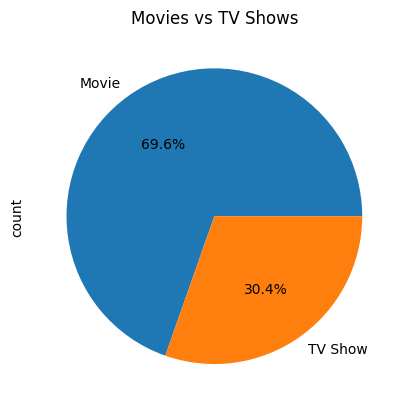

In [76]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()

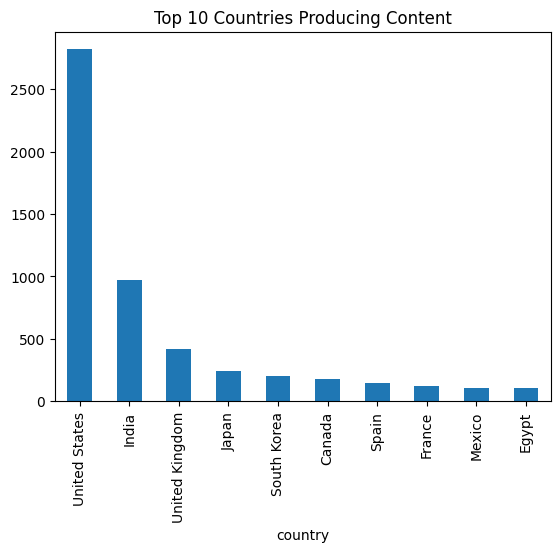

In [75]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries Producing Content")
plt.show()

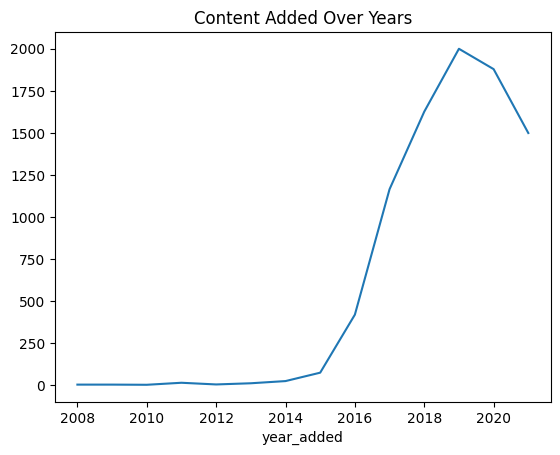

In [74]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.show()

In [60]:
df['listed_in'].str.split(',').explode().value_counts().head(10)

,count
listed_in,
International Movies,2624
Dramas,1600
Comedies,1210
Action & Adventure,859
Documentaries,829
Dramas,827
International TV Shows,774
Independent Movies,736
TV Dramas,696


In [69]:
# split genres and count them
genre_counts = df['listed_in'].str.split(',').explode().str.strip().value_counts()

# top 10 genres
top_genres = genre_counts.head(10)

top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


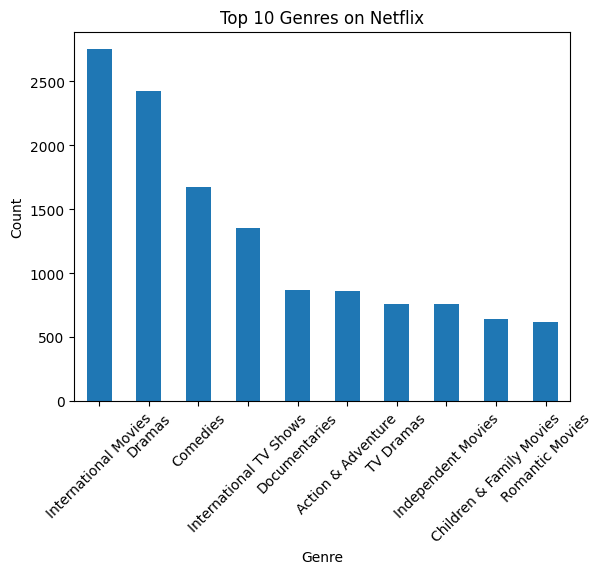

In [67]:
top_genres.plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

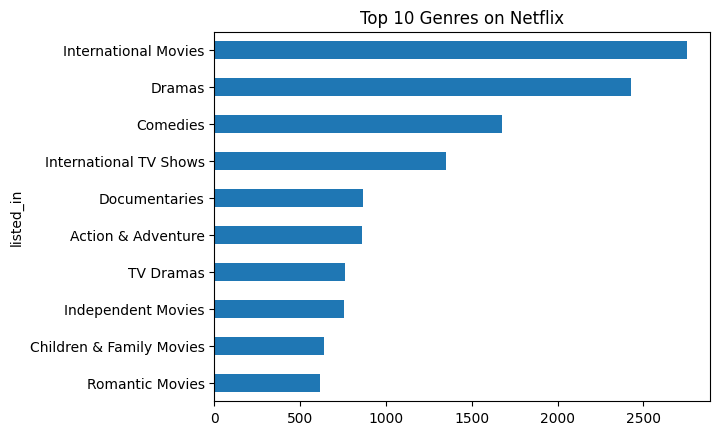

In [68]:
top_genres.sort_values().plot(kind='barh')
plt.title("Top 10 Genres on Netflix")
plt.show()

## 🔍 Final Insights

- Netflix content is dominated by Movies over TV Shows  
- USA is the leading content producer  
- Content growth increased significantly after 2015  
- Drama and Comedy are the most common genres  

## 🚀 Conclusion

Netflix has expanded rapidly in recent years, focusing heavily on movie content and popular genres like drama and comedy.